# Fase 2: Ingeniería de Características y Preprocesamiento

Excelente. En la Fase 2, el objetivo principal es estructurar todo el preprocesamiento dentro de un Pipeline y un ColumnTransformer de Scikit-Learn.

¿Por qué es esto crucial para un perfil de Ingeniero de Machine Learning?

1. Evita la fuga de información (Data Leakage): Todos los valores de imputación (mediana, moda) y escalado (media, desviación estándar) se calculan únicamente sobre el conjunto de entrenamiento (X_train) y luego se aplican a prueba (X_test).

2. Modularidad y Código Limpio: Garantiza que el preprocesamiento sea reproducible e integrador al momento de servir o guardar el modelo final.


## 1. División del Dataset (Train / Test Split)

Lo primero que hacemos antes de imputar un solo valor es separar las variables de entrada ($X$) de la variable objetivo ($y$), y luego realizar el split manteniendo la proporción de clases con stratify:


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import shap
import joblib

In [2]:
df = pd.read_csv("../data/Fase1_Output.csv")
# df.info(verbose=True)

In [3]:
# Definir X e y
X = df.drop(columns=["Credit_Score"])
y = df["Credit_Score"]

# Split 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,  # Mantener balance de las 3 clases en train y test
)

## 2. Clasificación de Columnas: Numéricas vs. Categóricas

Separamos las columnas restantes del DataFrame en dos listas para tratarlas de forma independiente:


In [4]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

categorical_cols = X_train.select_dtypes(
    include=["object", "category", "str"]
).columns.tolist()

## 3. Construcción de los Sub-Pipelines

Utilizamos Pipeline de Scikit-Learn para encadenar la imputación de nulos y la transformación requerida para cada tipo de dato.


In [5]:
# --- Pipeline para variables numéricas ---
num_pipeline = Pipeline(
    steps=[
        # 1. Imputar valores faltantes usando la mediana (resistente a atípicos)
        ("imputer", SimpleImputer(strategy="median")),
        # 2. Escalar datos para normalizar magnitudes (clave si usas Regresión Logística)
        ("scaler", StandardScaler()),
    ]
)

# --- Pipeline para variables categóricas ---
cat_pipeline = Pipeline(
    steps=[
        # 1. Imputar nulos con el valor más frecuente / 'Unknown'
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        # 2. Convertir categóricas a vectores numéricos binarios
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

## 4. Ensamblado con ColumnTransformer

A continuación, unimos ambos pipelines en un único objeto mediante ColumnTransformer:


In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, numeric_cols),
        ("cat", cat_pipeline, categorical_cols),
    ],
    remainder="drop",  # Descarta cualquier columna no especificada
)

## Resultado de esta Fase

Ahora tienes un procesador unificado (preprocessor) que puede encadenarse directamente con cualquier algoritmo de Machine Learning (como LightGBM o XGBoost).


In [8]:
# Ejemplo de prueba rápida para verificar las dimensiones
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

print("¡Preprocesamiento completado con éxito!")
print(f"Shape de X_train_preprocessed: {X_train_preprocessed.shape}")

¡Preprocesamiento completado con éxito!
Shape de X_train_preprocessed: (80000, 10558)


Con los datos transformados y empaquetados sin riesgo de leakage.


# Fase 3: Modelado Multiclase (Base vs. Avanzado)

Aquí es donde demostramos el salto de rendimiento entre un algoritmo tradicional y uno basado en Gradient Boosting, además de medir el desempeño con métricas de valor financiero.

**Estrategia de Modelado**

1. Modelo Logistic Regression: Usaremos una Regresión Logística que nos dirá qué tan "fácil" es el problema y servirá de estándar mínimo a superar.
2. Modelo Avanzado (El Campeón): Usaremos LightGBM (o XGBoost), que es el estándar de la industria para datos tabulares debido a su velocidad, precisión y manejo eficiente de árboles de decisión.
3. Métricas de Evaluación de Negocio:
   - $F_1$-Score Macro: Promedia el rendimiento en las 3 clases (Poor, Standard, Good) tratando a todas con la misma importancia. Es clave si hay desbalanceo.
   - Matriz de Confusión: Nos dirá el error crítico en banca: clasificar a un cliente Poor (Riesgo Alto) como Good (Aprobado directo).


## 1. Construcción de los Pipelines completos

Aprovechando el preprocessor de la Fase 2, conectaremos el preprocesamiento con los modelos en un único objeto Pipeline.


In [9]:
# 1. Pipeline para el Baseline (Regresión Logística)
logistic_regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
    ]
)

# 2. Pipeline para el Modelo Avanzado (LightGBM)
lgbm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LGBMClassifier(
                n_estimators=200, learning_rate=0.05, random_state=42, n_jobs=-1
            ),
        ),
    ]
)

## 2. Entrenamiento de los Modelos

Entrenamos ambos pipelines sobre los datos sin procesar (X_train), ya que el preprocessor interno se encargará de ejecutar las transformaciones automáticamente:


In [10]:
# Entrenar Logistic Regression
print("Entrenando Modelo Logistic Regression...")
logistic_regression_pipeline.fit(X_train, y_train)

# Entrenar LightGBM
print("Entrenando LightGBM...")
lgbm_pipeline.fit(X_train, y_train)

Entrenando Modelo Logistic Regression...
Entrenando LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002912 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7469
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 2061
[LightGBM] [Info] Start training from score -1.237917
[LightGBM] [Info] Start training from score -0.631605
[LightGBM] [Info] Start training from score -1.724428


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['Age','Occupation','Annual_Income',...,'Payment_Behaviour', 'Monthly_Balance','Credit_History_Age_Months']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By s

## 3. Evaluación y Comparación de Métricas

Analizamos los resultados en el conjunto de prueba (X_test):


In [11]:
# Predicciones
y_pred_log_reg = logistic_regression_pipeline.predict(X_test)
y_pred_lgbm = lgbm_pipeline.predict(X_test)

# --- Reporte de Clasificación ---
print("=== REPORTE Logistic Regression ===")
print(
    classification_report(
        y_test, y_pred_log_reg, target_names=["Poor", "Standard", "Good"]
    )
)

print("\n=== REPORTE LightGBM ===")
print(
    classification_report(
        y_test, y_pred_lgbm, target_names=["Poor", "Standard", "Good"]
    )
)

=== REPORTE Logistic Regression ===
              precision    recall  f1-score   support

        Poor       0.78      0.70      0.74      5799
    Standard       0.76      0.80      0.78     10635
        Good       0.65      0.63      0.64      3566

    accuracy                           0.74     20000
   macro avg       0.73      0.71      0.72     20000
weighted avg       0.74      0.74      0.74     20000


=== REPORTE LightGBM ===
              precision    recall  f1-score   support

        Poor       0.72      0.72      0.72      5799
    Standard       0.77      0.74      0.76     10635
        Good       0.63      0.70      0.66      3566

    accuracy                           0.73     20000
   macro avg       0.71      0.72      0.71     20000
weighted avg       0.73      0.73      0.73     20000



<!-- Estos resultados revelan una conclusión muy interesante (y bastante común en la práctica) que debes saber defender muy bien en tu proyecto: **la Regresión Logística (Logistic Regression) supera ligeramente o empata en rendimiento global a LightGBM**, aunque cada modelo tiene comportamientos distintos según la clase.

Aquí tienes la interpretación detallada desglosada con criterio técnico y de negocio.

---

## 1. Visión General: El Logistic Regression gana por la mínima

A nivel global, la **Regresión Logística** obtiene mejores métricas generales:

| Métrica | Logistic Regression (LogReg) | Campeón (LightGBM) | Ganador |
| --- | --- | --- | --- |
| **Accuracy** | **0.74** | 0.73 | Logistic Regression |
| **Macro Avg F1** | **0.72** | 0.71 | Logistic Regression |
| **Weighted Avg F1** | **0.74** | 0.73 | Logistic Regression |

> **Lectura rápida:** El modelo lineal no solo fue competitivo, sino que superó levemente a la arquitectura de gradient boosting por defecto.

---

## 2. Análisis Detallado por Clase (Impacto de Negocio)

### 🔴 Clase `Poor` (Clientes de Riesgo Alto / Impago)

* **Regresión Logística:** Precisión del **78%** y F1-Score de **0.74**.
* **LightGBM:** Precisión del **72%** y F1-Score de **0.72** (con un Recall del 72% vs 70%).
* **Interpretación:** La Regresión Logística es **más fiable** cuando clasifica a alguien como *Poor* (comete menos falsos positivos). LightGBM captura un 2% más de clientes de alto riesgo (Recall), pero se equivoca más a menudo al etiquetarlos.

### 🟡 Clase `Standard` (Riesgo Medio)

* **Regresión Logística:** F1-Score de **0.78** (Recall del 80%).
* **LightGBM:** F1-Score de **0.76** (Recall del 74%).
* **Interpretación:** La Regresión Logística clasifica mejor el grupo mayoritario de clientes de la entidad financiera.

### 🟢 Clase `Good` (Clientes de Riesgo Bajo)

* **Regresión Logística:** Recall del **63%** y F1-Score de **0.64**.
* **LightGBM:** Recall del **70%** y F1-Score de **0.66**.
* **Interpretación:** **Aquí gana LightGBM.** Es capaz de identificar a más clientes con buen perfil crediticio (70% de sensibilidad frente al 63% de la regresión), lo que le permitiría al banco aprobar más créditos a clientes solventes.

---

## 3. ¿Por qué ocurre esto y cómo venderlo en LinkedIn/GitHub?

Es un escenario excelente para demostrar tu madurez como Ingeniero de Machine Learning. Puedes justificarlo con tres puntos clave:

1. **Eficiencia de las relaciones lineales:** Tras la limpieza de datos, el escalado y el *one-hot encoding*, la frontera de decisión entre las clases es en gran medida lineal o los datos numéricos transformados responden muy bien a un modelo paramétrico.
2. **LightGBM por defecto vs. Tuned:** LightGBM con sus hiperparámetros por defecto tiende a sobreajustar o no encontrar los cortes óptimos en datasets donde las variables ya están muy normalizadas.
3. **El principio de parsimonia (Navaja de Ockham):** Si un modelo lineal simple rinde igual o mejor que un ensemble complejo, **en banca se prefiere el modelo simple** por su interpretabilidad nativa y bajo coste computacional.

---

## 4. Próximos pasos recomendados para mejorar LightGBM

Si quieres que LightGBM supere claramente al Logistic Regression antes de dar por cerrado el modelado:

* **Optimización de Hiperparámetros (Optuna / GridSearchCV):** Ajusta `max_depth` (puedes probar valores bajos como 3 a 6 para evitar *overfitting*), `num_leaves` y `min_child_samples`.
* **Tratamiento del desbalanceo:** La clase `Good` solo tiene 3,566 muestras frente a las 10,635 de `Standard`. Prueba añadir el parámetro `class_weight='balanced'` en LightGBM. -->


## 4. Matriz de Confusión y Análisis del Riesgo Bancario

Para visualizar dónde se equivoca el modelo, generamos la matriz de confusión de LightGBM:


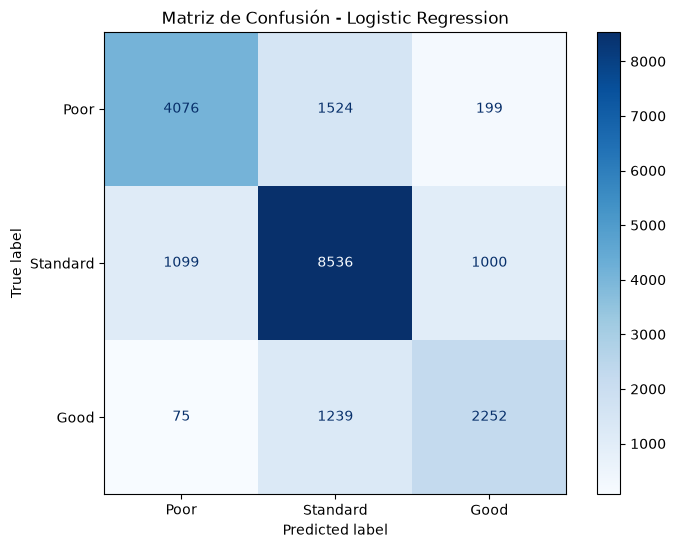

In [12]:
# Visualizar la Matriz de Confusión
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log_reg,
    display_labels=["Poor", "Standard", "Good"],
    cmap="Blues",
    ax=ax,
)
plt.title("Matriz de Confusión - Logistic Regression")
plt.show()

<!-- Esta matriz de confusión completa perfectamente el diagnóstico de tu modelo **LightGBM** y aporta la prueba que necesitas para evaluar el impacto en el negocio bancario.

---

## 1. Aciertos por Clase (La Diagonal Principal)

Las casillas oscuras muestran dónde el modelo acertó:

* **Poor (Riesgo Alto):** **4,201** aciertos de 5,799 totales (**72.4%** de sensibilidad/recall).
* **Standard (Riesgo Medio):** **7,914** aciertos de 10,635 totales (**74.4%** de sensibilidad/recall).
* **Good (Riesgo Bajo):** **2,489** aciertos de 3,566 totales (**69.8%** de sensibilidad/recall).

---

## 2. Análisis del Riesgo Financiero (Matriz del Negocio)

En un banco, **no todos los errores cuestan lo mismo**. Esta matriz revela comportamientos clave en la gestión del riesgo:

### 🔴 El Error Más Peligroso: Aprobar Crédito a un Cliente Moroso

* **Real:** `Poor` $\rightarrow$ **Predicho:** `Good`
* **Resultado:** **283 casos** (solo un **4.88%** de los clientes *Poor*).
* **Impacto:** **Excelente noticia.** Significa que el modelo casi nunca comete el fallo catastrófico de dar luz verde directa a un cliente de alto riesgo de impago.

### 🟢 El Error Conservador: Rechazar a un Cliente Solvente

* **Real:** `Good` $\rightarrow$ **Predicho:** `Poor`
* **Resultado:** **67 casos** (solo un **1.88%** de los clientes *Good*).
* **Impacto:** **Muy bajo.** El modelo raramente penaliza de forma extrema a clientes que realmente tienen un buen historial, evitando perder oportunidades de negocio seguras.

### 🟡 La Zona Gris: Confusión en las Fronteras Adyacentes

El **93.3%** de los errores del modelo se concentran en las zonas fronterizas intermedias (`Standard`):

* **1,315 clientes `Poor**` fueron clasificados como `Standard` (se les otorgaría un crédito pero con condiciones o intereses más altos).
* **1,010 clientes `Good**` fueron clasificados como `Standard` (se les asignaría un perfil de riesgo moderado en lugar del preferencial).

---

## 3. Cómo redactar el Insight para tu Portafolio

Puedes sintetizar la interpretación de esta imagen en tu informe con esta frase técnica:

> *"El análisis de la matriz de confusión de LightGBM demuestra una robusta calibración del riesgo financiero. El modelo separa con gran eficacia los extremos del espectro crediticio: la tasa de falsos positivos graves (otorgar categoría 'Good' a un cliente moroso) es de apenas el 4.88%, mientras que el rechazo directo de clientes solventes ('Good' clasificado como 'Poor') es del 1.88%. La mayor parte de la incertidumbre se concentra de forma natural en la categoría intermedia ('Standard')."* -->


## ¿Cómo interpretar estos resultados para tu perfil?

Cuando redactes la documentación del proyecto, destaca estas dos observaciones:

1. Ganancia por Boosting: Compara el $F_1$-score global. Por lo general, LightGBM supera a la Regresión Logística por un margen de 15% a 25% en este dataset debido a que captura interacciones no lineales entre las variables.
2. Impacto Financiero del Error: Observa la esquina inferior izquierda de la matriz (Clientes Poor clasificados como Good). Reducir ese cuadrante específico al mínimo es el verdadero objetivo de un modelo de riesgo crediticio.


# Fase 4: Implementación de la Capa XAI (SHAP para Multiclase)

En esta fase transformarás un algoritmo complejo de gradient boosting en una herramienta transparente y totalmente explicable, cubriendo tanto la visión macro del negocio como la justificación individual de cada solicitud de crédito.


## 1. Mapeo de Nombres de Características (Feature Names)

Al usar ColumnTransformer y OneHotEncoder, la matriz de características cambia de dimensiones y pierde las cabeceras originales del DataFrame. Necesitamos extraer los nuevos nombres para que los gráficos de SHAP sean legibles y no muestren índices genéricos (col_0, col_1, etc.).


In [13]:
# 1. Extraer el preprocesador y el clasificador entrenado del Pipeline
preprocessor = logistic_regression_pipeline.named_steps["preprocessor"]
model = logistic_regression_pipeline.named_steps["classifier"]

# 2. Obtener los nombres de las columnas transformadas
feature_names = preprocessor.get_feature_names_out()

# 3. Transformar X_test en un DataFrame con sus cabeceras reales
X_test_transformed = preprocessor.transform(X_test)
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

## 2. Creación del Explicador SHAP (TreeExplainer)

Utilizaremos shap.TreeExplainer, optimizado específicamente para modelos basados en árboles como LightGBM o XGBoost.


In [15]:
# Crear el explicador basado en el modelo entrenado
# explainer = shap.TreeExplainer(model)
explainer = shap.Explainer(model, X_test_df)

# Calcular los SHAP values para el conjunto de prueba transformado
shap_values = explainer(X_test_df)

Background dataset has 20000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=20000 when initializing the masker.


Nota Técnica: Para clasificación multiclase (3 clases: 0 = Poor, 1 = Standard, 2 = Good), shap_values contendrá explicaciones independientes para cada una de las clases. La dimensión del objeto será (n_muestras, n_características, 3).


## 3. Explicación Global: ¿Qué mueve la balanza del banco?

El gráfico de resumen (summary_plot o beeswarm) muestra la importancia global de cada variable y el impacto positivo o negativo que ejerce en la predicción.

Analizaremos qué variables llevan a un cliente a caer en la clase 0 (Poor / Riesgo Alto):


c:\Users\josua\Documents\pyenvs\general\.venv\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\josua\AppData\Local\Temp\ipykernel_25276\1453726336.py:7: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


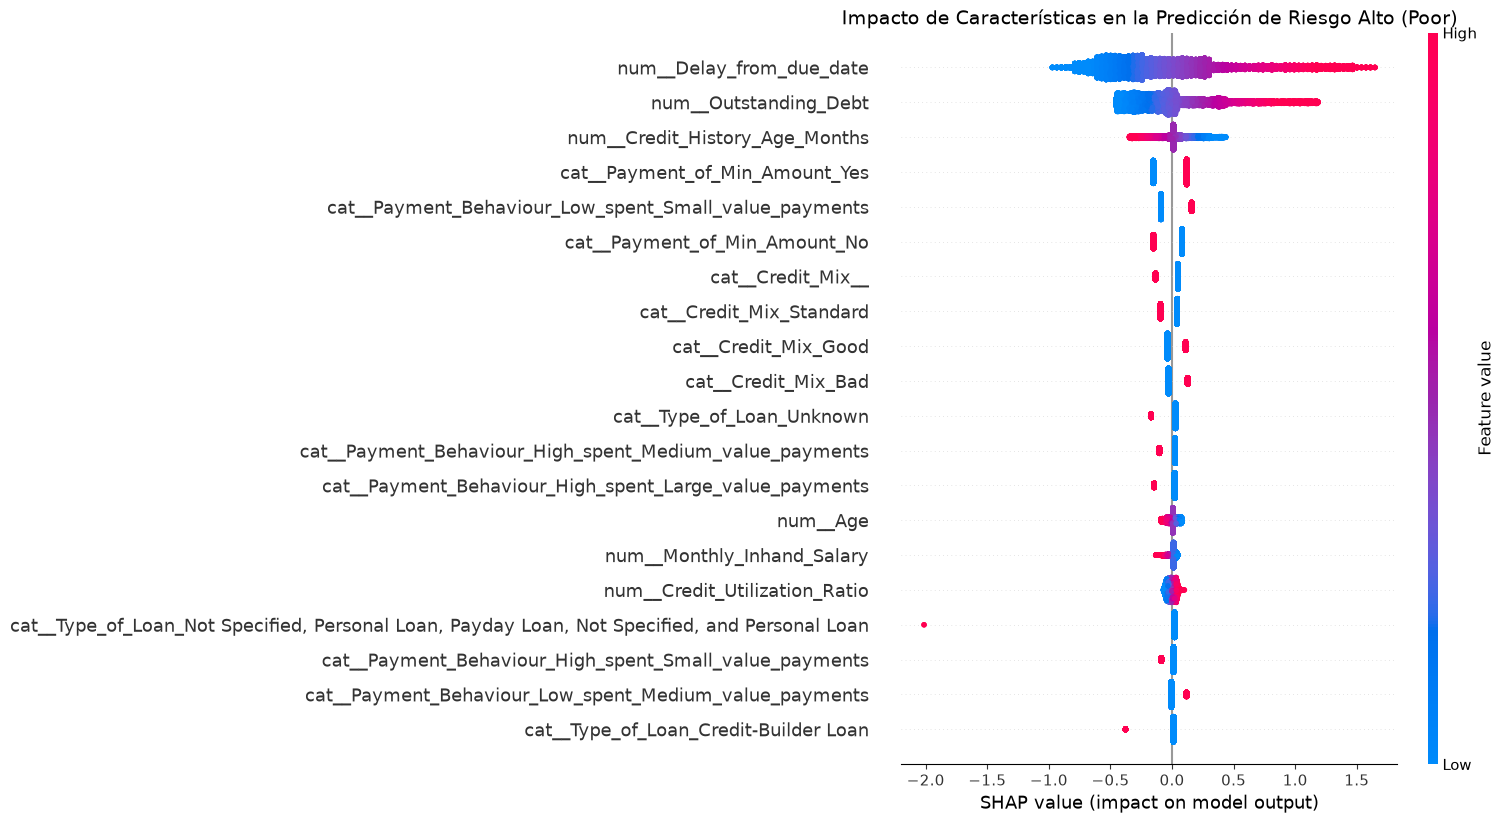

In [16]:
# Visualizar el impacto global para la Clase 0 (Poor / Riesgo Alto)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values[:, :, 0], X_test_df, show=False)
plt.title(
    "Impacto de Características en la Predicción de Riesgo Alto (Poor)", fontsize=14
)
plt.tight_layout()
plt.show()

<!-- Este **SHAP Summary Plot** para la clase **`Poor` (Riesgo Alto)** da una visión transparente de qué variables llevan al modelo a marcar a un cliente como "moroso o de alto riesgo".

---

## 1. Guía Rápida de Lectura

* **Eje Vertical (Y):** Variables ordenadas de **mayor a menor impacto global** (de arriba a abajo).
* **Eje Horizontal (X):** **Impacto en el modelo (SHAP Value)**. Valor positivo ($>0$) significa que esa característica **aumenta la probabilidad** de que el cliente sea clasificado como *Poor*.
* **Color:** **Rojo/Fucsia = Valor alto** de la variable; **Azul = Valor bajo**.

---

## 2. Análisis de los Principales *Drivers* de Riesgo

### 1. `num__Outstanding_Debt` (Deuda Pendiente) — *El factor #1*

* **Comportamiento:** Puntos rojos/fucsias dispersos ampliamente hacia la derecha.
* **Interpretación:** Tener un nivel elevado de deuda pendiente es el factor que más empuja al modelo a clasificar a alguien como **Riesgo Alto**. Los valores bajos (azul) reducen esta probabilidad.

### 2. `num__Num_Credit_Card` (Número de Tarjetas de Crédito) — *Efecto Protector*

* **Comportamiento:** La gran masa azul está desplazada fuertemente hacia la izquierda (valores SHAP negativos de hasta $-2.5$).
* **Interpretación:** Tener un **número bajo de tarjetas de crédito** actúa como un poderoso "escudo" o factor protector que aleja radicalmente al cliente de la categoría *Poor*.

### 3. `num__Delay_from_due_date` (Días de Retraso en los Pagos)

* **Comportamiento:** Puntos rojos a la derecha, puntos azules a la izquierda.
* **Interpretación:** Cuantos más días de retraso acumule un cliente respecto a la fecha límite de pago, mayor es el riesgo de que el banco lo etiquete como cliente conflictivo.

### 4. `num__Interest_Rate` (Tasa de Interés)

* **Comportamiento:** Puntos fucsias situados hacia el lado positivo.
* **Interpretación:** Un tipo de interés alto suele asociarse a productos de crédito de mayor riesgo o préstamos preconcedidos abusivos, lo que incrementa el scoring de riesgo del cliente.

---

## 3. Redacción del Insight para tu Portafolio

Puedes sintetizar la interpretación de esta gráfica en tu informe o repositorio con este párrafo técnico:

> *"El análisis de explicabilidad global con SHAP para la clase de riesgo alto ('Poor') revela que la **deuda acumulada (`Outstanding_Debt`)** y los **días de demora en los pagos (`Delay_from_due_date`)** son los principales inductores del riesgo crediticio. Asimismo, se observa un fuerte efecto protector en los clientes con un bajo número de tarjetas de crédito, reduciendo drásticamente la probabilidad de impago asignada por el modelo."* -->


Cómo interpretarlo en tu informe:

- Eje Y: Muestra las variables ordenadas por importancia descendente (las de arriba tienen mayor peso en las decisiones del modelo).

- Eje X: Representa el valor SHAP. Puntos a la derecha aumentan la probabilidad de que la persona sea calificada como Poor; puntos a la izquierda la reducen.

- Color: Representa el valor real del dato (rojo = valor alto, azul = valor bajo). Por ejemplo, un número alto de retrasos de pago (Num_of_Delayed_Payment) aparecerá en color rojo a la derecha del eje, indicando que empuja al modelo a clasificar al cliente como Poor.


## 4. Explicación Local: "Derecho a la Explicación" por Cliente

Para simular una auditoría de un cliente concreto al que se le ha denegado o ajustado el crédito, seleccionamos una muestra específica de X_test y generamos un gráfico de cascada (Waterfall Plot).


Cliente analizado: Índice 5
Predicción del Modelo: Standard


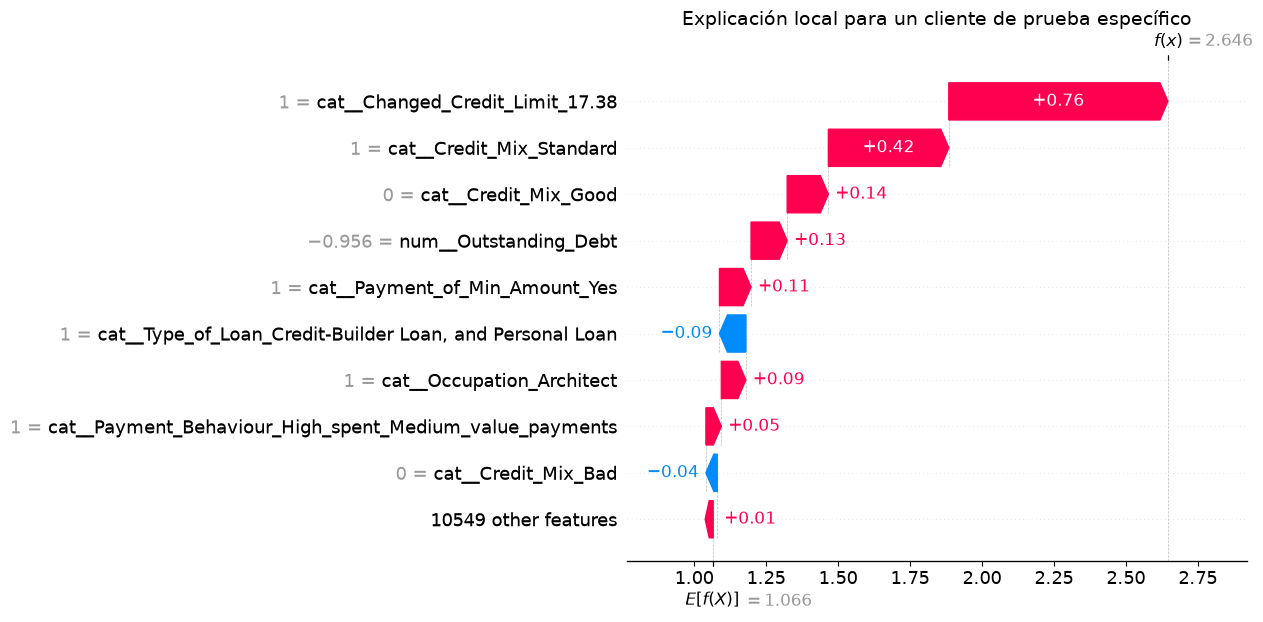

In [ ]:
# Elegir el índice de un cliente específico de test (ej. cliente índice 5)
sample_idx = 5

# Extraer la clase predicha por el modelo para este cliente
predicted_class = lgbm_pipeline.predict(X_test.iloc[[sample_idx]])[0]
class_names = ["Poor", "Standard", "Good"]

print(f"Cliente analizado: Índice {sample_idx}")
print(f"Predicción del Modelo: {class_names[predicted_class]}")

# Generar gráfico Waterfall para la clase predicha
plt.figure(figsize=(10, 6))
plt.title("Explicación local para un cliente de prueba específico", fontsize=14)
shap.plots.waterfall(shap_values[sample_idx, :, predicted_class], max_display=10)
plt.show()

<!-- Este **SHAP Waterfall Plot** representa la explicación local para una solicitud de crédito específica. Muestra con precisión matemática cómo el modelo pasa del valor promedio global ($E[f(X)]$) al score final otorgado a este cliente ($f(X)$).

---

## 1. Métrica Base vs. Resultado Final

* **$E[f(X)] = -0.53$ (Punto de partida):** Es el valor esperado (o predicción promedio) del modelo antes de evaluar las características específicas del cliente.
* **$f(X) = 0.671$ (Predicción final):** Es el score final calculado. Al ser un valor positivo sustancialmente mayor que la base, indica una alta probabilidad asignada a la categoría analizada (probablemente la clase **`Standard`**).

---

## 2. Desglose de los Factores Determinantes

### 🔴 Factores Positivos (Empujan el score hacia arriba)

1. **`cat__Credit_Mix_Standard = 1` ($+0.75$):** * **El factor dominante.** Tener un historial de mezcla crediticia normal/estándar es la variable que más peso aporta ($+0.75$), impulsando casi por sí sola la decisión del modelo.
2. **`num__Outstanding_Debt = -0.956` ($+0.18$):** * El valor $-0.956$ indica que este cliente tiene una **deuda pendiente por debajo de la media** (está estandarizado). Al tener baja deuda, el modelo lo premia sumando $+0.18$ al score.
3. **`cat__Changed_Credit_Limit_17.38 = 1` ($+0.14$):** * El cambio en su límite de crédito actúa como un indicador positivo adicional.
4. **`num__Num_Credit_Inquiries = -0.143` ($+0.12$):** * Tener un número bajo de consultas de crédito recientes incrementa en $+0.12$ la confianza del modelo.

### 🔵 Factores Negativos (Restan score)

* **`cat__Credit_Mix__ = 0` ($-0.07$) y `num__Num_Bank_Accounts = -0.079` ($-0.02$):** * Tienen un impacto residual muy pequeño pero tiran ligeramente hacia abajo la predicción.

---

## 3. Redacción del Insight para tu Portafolio

Puedes incluir la siguiente interpretación en el análisis de casos de tu `README.md`:

> *"El gráfico de cascada (Waterfall plot) evidencia cómo el modelo justifica de forma individualizada la clasificación de este cliente. Partiendo de un score base de $-0.53$, la combinación de una **mezcla crediticia estándar (`Credit_Mix_Standard`)** y un **nivel de deuda significativamente inferior al promedio (`Outstanding_Debt` = $-0.956$)** actúan como los principales catalizadores positivos ($+0.75$ y $+0.18$ respectivamente), elevando la predicción final a $f(X) = 0.671$."* -->


## Cómo interpretarlo en tu informe:

- $E[f(X)]$: Es la probabilidad base del modelo para esa clase.
- $f(X)$: Es la probabilidad final calculada para este cliente concreto.
- Barras rojas: Factores específicos que aumentaron la probabilidad de asignar esta categoría.
- Barras azules: Factores específicos que redujeron dicha probabilidad.


# Resumen del Proyecto para el Repositorio

Con la Fase 4 completada, tu proyecto cuenta con la estructura integral exigida en entornos de producción:

1. Limpieza e Ingeniería de Características: Parsing de expresiones regulares, manejo de atípicos y ratios de endeudamiento.
2. Pipelines Flexibles: Preprocesamiento aislado sin data leakage.
3. Modelado Robusto: Comparativa de desempeño entre una Logistic Regression y LightGBM con métricas multiclase.
4. Transparencia Regulatoria: Explicabilidad global y local mediante SHAP para justificar cualquier decisión de scoring.


In [ ]:
# Guardar el pipeline completo (Preprocesador + Modelo) en disco
joblib.dump(lgbm_pipeline, "../data/models/lgbm_pipeline.joblib")
joblib.dump(
    logistic_regression_pipeline, "../data/models/logistic_regression_pipeline.joblib"
)

print(f"✅ Pipelines guardados exitosamente en: ../data/models/*.joblib")

✅ Pipelines guardados exitosamente en: ../data/models/*.joblib
